In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import time
from IPython.display import display
import io
from PIL import Image

In [3]:
from lsb.lsb import LSB
from dct.dct import DCT
from steganogan import SteganoGAN

In [4]:
secret_message  = 'taka21'

In [5]:
steganoGAN = SteganoGAN.load(path='../steganoGAN/pretrained/dense.steg')
dct_tool = DCT()
lsb_tool = LSB()

C:\Users\KietVu\Testplace\SteganoGAN\.venv\lib\site-packages\torch\serialization.py:786: SourceChangeWarning: source code of class 'torch.nn.modules.container.Sequential' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
C:\Users\KietVu\Testplace\SteganoGAN\.venv\lib\site-packages\torch\serialization.py:786: SourceChangeWarning: source code of class 'torch.nn.modules.conv.Conv2d' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
C:\Users\KietVu\Testplace\SteganoGAN\.venv\lib\site-packages\torch\serialization.py:786: SourceChangeWarning: source code of class 'torch.nn.modules.activation.LeakyReLU' has changed. you can retrieve the 

In [6]:
# 1. Load and prepare the dataset
image_dir = "data/div2k/val/DIV2K_valid_HR"
image_files = [f for f in sorted(os.listdir(image_dir)) if f.endswith(('.png'))]


In [7]:
# 2. Create a DataFrame to store results
results = []

In [8]:
from utils.utils import calculate_psnr, calculate_ssim

# 3. Process each image with all three methods
for img_file in tqdm(image_files, desc="Processing Images"):
    # Load original image
    img_path = os.path.join(image_dir, img_file)
    original = cv2.imread(img_path)
    # Get original file size
    original_size = os.path.getsize(img_path)

    # Dictionary to store results for this image
    img_results = {
        'image_name': img_file,
        'original_size': original_size
    }

    # Create temporary storage paths for stego images
    temp_lsb = "temp_lsb.png"
    temp_dct = "temp_dct.png"
    temp_gan = "temp_gan.png"

    # Apply each steganography method and measure metrics
    for method_name, temp_path in [
        ('LSB', temp_lsb),
        ('DCT', temp_dct),
        ('GAN', temp_gan)
    ]:
        try:
            # Time the encoding process
            start_time = time.time()
            if method_name == 'LSB':
                # lsb = LSBSteg(original)
                # stego = lsb.encode_text(secret_message)
                stego = lsb_tool.encode_message(img_path,temp_path,secret_message)
            elif method_name == 'DCT':
                stego = dct_tool.encode_image(original,secret_message)
            else:
                stego = steganoGAN.encode(img_path, temp_path, secret_message)

            encoding_time = time.time() - start_time

            # Save the stego image temporarily to get file size
            cv2.imwrite(temp_path, stego)
            stego_size = os.path.getsize(temp_path)

            # Calculate PSNR and SSIM
            psnr_value = calculate_psnr(original, stego)
            ssim_value = calculate_ssim(original, stego)

            # Store metrics
            img_results[f'{method_name}_psnr'] = psnr_value
            img_results[f'{method_name}_ssim'] = ssim_value
            img_results[f'{method_name}_size'] = stego_size
            img_results[f'{method_name}_size_ratio'] = stego_size / original_size
            img_results[f'{method_name}_time'] = encoding_time

        except Exception as e:
            # Log errors but continue with other methods/images
            print(f"Error processing {img_file} with {method_name}: {e}")
            img_results[f'{method_name}_psnr'] = np.nan
            img_results[f'{method_name}_ssim'] = np.nan
            img_results[f'{method_name}_size'] = np.nan
            img_results[f'{method_name}_size_ratio'] = np.nan
            img_results[f'{method_name}_time'] = np.nan

        # Clean up temporary file
        if os.path.exists(temp_path):
            os.remove(temp_path)
    # Add this image's results to the main results list
    results.append(img_results)

Processing Images:   0%|          | 0/100 [00:00<?, ?it/s]

In [9]:
# 4. Convert results to DataFrame
df_results = pd.DataFrame(results)

# 5. Display summary statistics
print("Summary Statistics:")
summary = df_results[['LSB_psnr', 'DCT_psnr', 'GAN_psnr',
                      'LSB_ssim', 'DCT_ssim', 'GAN_ssim',
                      'LSB_size_ratio', 'DCT_size_ratio', 'GAN_size_ratio',
                      'LSB_time', 'DCT_time', 'GAN_time']].describe()

Summary Statistics:


In [10]:
display(summary)

,LSB_psnr,DCT_psnr,GAN_psnr,LSB_ssim,DCT_ssim,GAN_ssim,LSB_size_ratio,DCT_size_ratio,GAN_size_ratio,LSB_time,DCT_time,GAN_time
count,100.000000,100.000000,100.000000,1.000000e+02,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,102.481908,37.012366,37.834152,1.000000e+00,0.967231,0.943443,1.101094,1.062805,1.288434,1.697982,1.086336,5.035671
std,0.717677,3.809378,1.858366,3.173013e-09,0.017542,0.040268,0.046663,0.056940,0.493167,0.367595,0.146460,2.261154
min,100.930825,27.622646,31.854192,1.000000e+00,0.857536,0.686282,1.008783,0.940920,1.027504,0.905026,0.635014,2.816276
25%,102.041409,34.015409,36.809784,1.000000e+00,0.959648,0.939407,1.073159,1.028596,1.144346,1.480277,1.001207,4.320449
50%,102.433556,37.109804,38.301509,1.000000e+00,0.971398,0.953921,1.088885,1.057126,1.205454,1.667245,1.048286,4.608256
75%,102.874154,39.458475,39.021640,1.000000e+00,0.976862,0.965345,1.120263,1.088064,1.255409,1.882504,1.148937,5.115155
max,104.181003,47.170049,40.670505,1.000000e+00,0.993070,0.981417,1.273835,1.267600,5.652466,3.066025,1.521708,25.442605


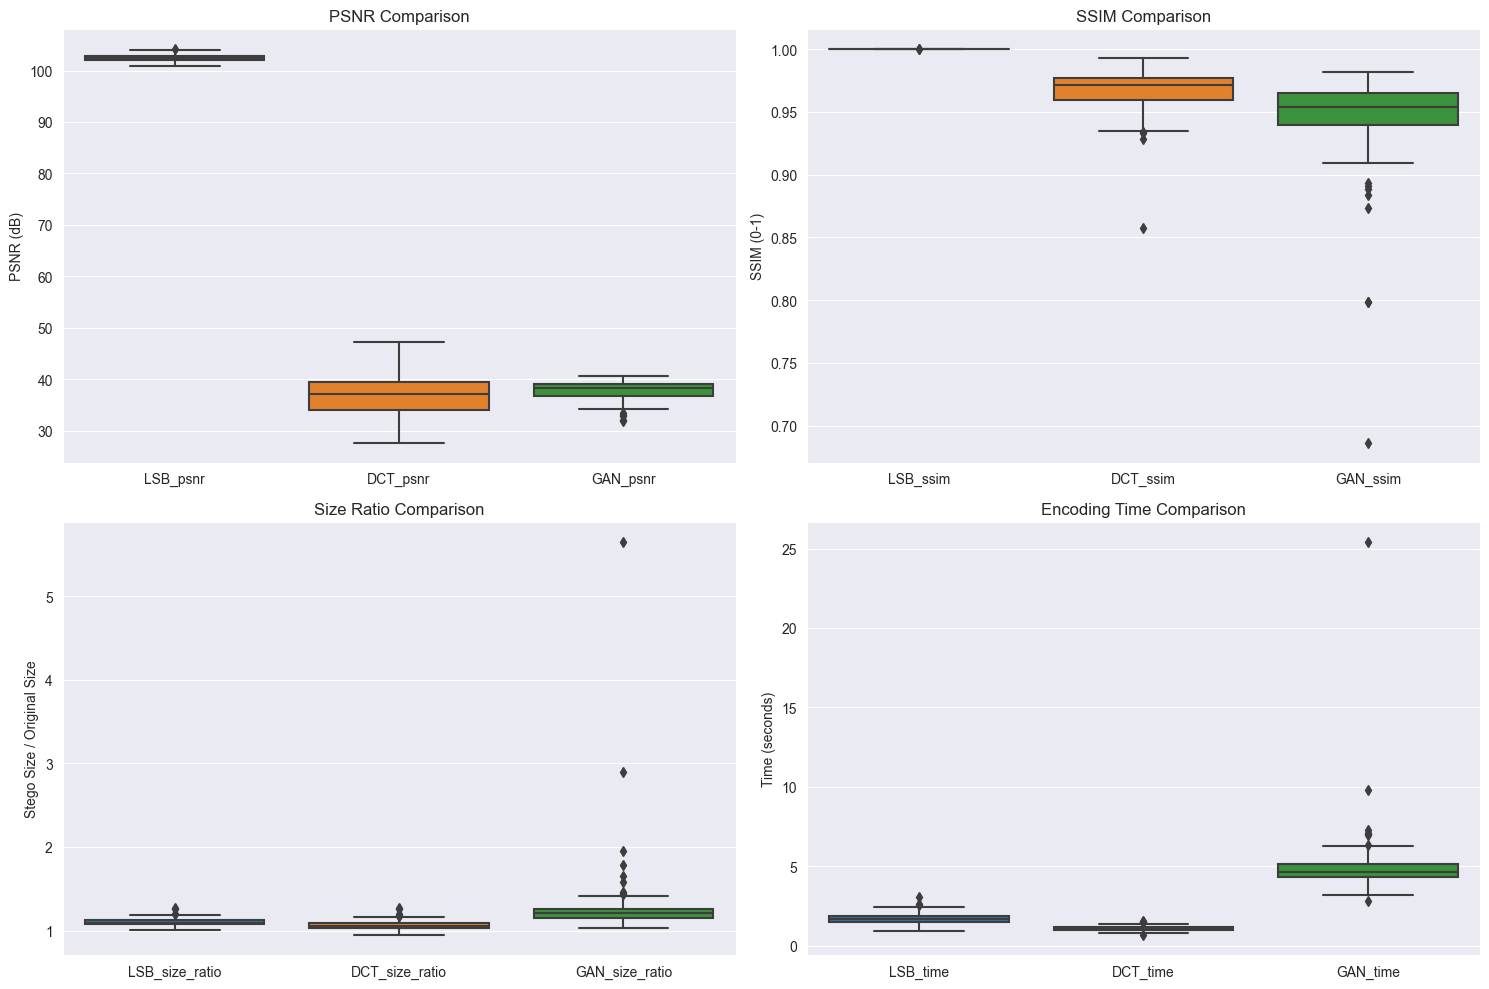

In [11]:
# 6. Visualize the results
plt.figure(figsize=(15, 10))

# PSNR Comparison
plt.subplot(2, 2, 1)
sns.boxplot(data=df_results[['LSB_psnr', 'DCT_psnr', 'GAN_psnr']])
plt.title('PSNR Comparison')
plt.ylabel('PSNR (dB)')

# SSIM Comparison
plt.subplot(2, 2, 2)
sns.boxplot(data=df_results[['LSB_ssim', 'DCT_ssim', 'GAN_ssim']])
plt.title('SSIM Comparison')
plt.ylabel('SSIM (0-1)')

# Size Ratio Comparison
plt.subplot(2, 2, 3)
sns.boxplot(data=df_results[['LSB_size_ratio', 'DCT_size_ratio', 'GAN_size_ratio']])
plt.title('Size Ratio Comparison')
plt.ylabel('Stego Size / Original Size')

# Encoding Time Comparison
plt.subplot(2, 2, 4)
sns.boxplot(data=df_results[['LSB_time', 'DCT_time', 'GAN_time']])
plt.title('Encoding Time Comparison')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

In [12]:
# 7. Statistical significance testing
from scipy import stats

print("\nStatistical Significance Tests (p-values):")
# PSNR tests
print("PSNR: LSB vs DCT:", stats.ttest_rel(df_results['LSB_psnr'], df_results['DCT_psnr']).pvalue)
print("PSNR: LSB vs GAN:", stats.ttest_rel(df_results['LSB_psnr'], df_results['GAN_psnr']).pvalue)
print("PSNR: DCT vs GAN:", stats.ttest_rel(df_results['DCT_psnr'], df_results['GAN_psnr']).pvalue)

# SSIM tests
print("\nSSIM: LSB vs DCT:", stats.ttest_rel(df_results['LSB_ssim'], df_results['DCT_ssim']).pvalue)
print("SSIM: LSB vs GAN:", stats.ttest_rel(df_results['LSB_ssim'], df_results['GAN_ssim']).pvalue)
print("SSIM: DCT vs GAN:", stats.ttest_rel(df_results['DCT_ssim'], df_results['GAN_ssim']).pvalue)


Statistical Significance Tests (p-values):
PSNR: LSB vs DCT: 1.7117296463539583e-123
PSNR: LSB vs GAN: 5.387161372157575e-152
PSNR: DCT vs GAN: 0.04790742176741136

SSIM: LSB vs DCT: 3.1833349160208285e-34
SSIM: LSB vs GAN: 2.6589503351069964e-25
SSIM: DCT vs GAN: 4.979864433655534e-06
